# **NLP Practical 01**
**Name:** Yesha Pandya

**Enrolment number:** 23BT04175

**Div:** 1 **Batch:** C

## **Objective:**
Read a text/ story/ journal / online review / any report. The
count of words should be more than 100 words


Write a Python program using NLTK to:
* Tokenize a paragraph into sentences and words.
* Remove stop words.
* Perform stemming on the remaining words.
* Perform lemmatization with POS

Write the synonyms and antonyms of any 5 words in the text. (First search whether the word is in the text (corpus). If yes then write their synonym and antonym, else print ('out of corpus')).

Design a regex pattern to validate phone numbers in the format +91-9/8XXXXXXXXX (India). Test it with at least 3 examples.

Use the regular expression functions to search a pattern and replace it with give pattern.

Use regular expression functions to list all the words starting with vowel.

Remove the words which are in the list of stop words and plot the remaining words
Using NLTK, write a script that:
* Tags each word in a sentence with its part of speech (POS).
* Extracts all nouns and verbs separately. (list them)
* Writes the number of adjectives and list the root word only

## **Step 1: Setup + Downloads**
Import required libraries + download the necessary NLTK datasets

In [1]:
import nltk
import re
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.probability import FreqDist

# NLTK packages
nltk.download('punkt', quiet=True) # Pre-trained model for sentence splitting and basic word tokenization
nltk.download('stopwords', quiet=True) # Data tables required by newer NLTK versions for tabular sentence tokenization
nltk.download('punkt_tab', quiet=True) # List of stopwords (for filtering)
nltk.download('wordnet', quiet=True) # Large English lexical database used for lemmatization, synonyms, antonyms
nltk.download('omw-1.4', quiet=True) # Open Multilingual WordNet data (provides expanded mappings for WordNet)
nltk.download('averaged_perceptron_tagger', quiet=True) # Pre-trained model that assigns Part-of-Speech (POS) tags
nltk.download('averaged_perceptron_tagger_eng', quiet=True) # English-specific model weights for the POS tagger

print("All NLTK dependencies downloaded successfully!")

All NLTK dependencies downloaded successfully!


## **Step 2: Load Source Corpus**

In [2]:
# Sarah J. Maas - A Court of Silver Flames Excerpt (Blood Rite)
sjm_text = """
The male emerged from the fog; tall - maybe taller than Aedion himself, if only by an inch,
powefully built, and heavily armed both above and beneath his pale grey surcoat and hood.
Aelin took a step forward. One step, as if in a daze.
She loosened a shuddering breath,and a small, whimpering noise came out of her - a sob.

And then she was sprinting down the alley,flying as though the winds themselves pushed at her heels.
She flung herself on the male, crashing into him hard enough that anyone else might have
gone rocking back into the stone wall. But not him.
Aelin was laughing as she cried, and the male was just holding her, his hooded head buried
in her neck. As if he were breathing her in.
"Who is that?" Nesryn asked.
Aedion smiled. "Rowan".
"""

sjm_text = sjm_text.strip()
raw_words = sjm_text.split()

print("CORPUS TEXT:")
print(sjm_text)
print(f"\nTotal Word Count: {len(raw_words)} words")

CORPUS TEXT:
The male emerged from the fog; tall - maybe taller than Aedion himself, if only by an inch,
powefully built, and heavily armed both above and beneath his pale grey surcoat and hood.
Aelin took a step forward. One step, as if in a daze.
She loosened a shuddering breath,and a small, whimpering noise came out of her - a sob.

And then she was sprinting down the alley,flying as though the winds themselves pushed at her heels. 
She flung herself on the male, crashing into him hard enough that anyone else might have 
gone rocking back into the stone wall. But not him. 
Aelin was laughing as she cried, and the male was just holding her, his hooded head buried
in her neck. As if he were breathing her in.
"Who is that?" Nesryn asked.
Aedion smiled. "Rowan".

Total Word Count: 139 words


## **Step 3: Sentence and Word Tokenization**

* Sentence Tokenization: Splitting text into individual sentence sequences based on sentence boundaries.
* Word Tokenization: Segmenting continuous text into atomic units (words and punctuation marks).

In [3]:
# Sentence Tokenization
sentences = sent_tokenize(sjm_text)
print(f"SENTENCE TOKENIZATION ({len(sentences)} Sentences Found)")
for i, sent in enumerate(sentences, 1):
    print(f"[{i}] {sent}")

# Word Tokenization
word_tokens = word_tokenize(sjm_text)
print(f"\nWORD TOKENIZATION (First 20 Tokens out of {len(word_tokens)})")
print(word_tokens[:20])

SENTENCE TOKENIZATION (13 Sentences Found)
[1] The male emerged from the fog; tall - maybe taller than Aedion himself, if only by an inch,
powefully built, and heavily armed both above and beneath his pale grey surcoat and hood.
[2] Aelin took a step forward.
[3] One step, as if in a daze.
[4] She loosened a shuddering breath,and a small, whimpering noise came out of her - a sob.
[5] And then she was sprinting down the alley,flying as though the winds themselves pushed at her heels.
[6] She flung herself on the male, crashing into him hard enough that anyone else might have 
gone rocking back into the stone wall.
[7] But not him.
[8] Aelin was laughing as she cried, and the male was just holding her, his hooded head buried
in her neck.
[9] As if he were breathing her in.
[10] "Who is that?"
[11] Nesryn asked.
[12] Aedion smiled.
[13] "Rowan".

WORD TOKENIZATION (First 20 Tokens out of 169)
['The', 'male', 'emerged', 'from', 'the', 'fog', ';', 'tall', '-', 'maybe', 'taller', 'than', 'Ae

## **Step 4: Stopword Removal**
Stop words (e.g., "the", "is", "and") are structural tokens that occur frequently but offer low semantic value.

Removing stop words and non-alphanumeric punctuation reduces noise for downstream tasks.

In [4]:
stop_words = set(stopwords.words('english'))

# Filter tokens: retain alphanumeric tokens not present in English stopwords
filtered_tokens = [w for w in word_tokens if w.isalnum() and w.lower() not in stop_words]

print(f"Original Token Count : {len(word_tokens)}")
print(f"Filtered Token Count : {len(filtered_tokens)}")
print("\nSample Filtered Tokens:")
print(filtered_tokens[:15])

Original Token Count : 169
Filtered Token Count : 67

Sample Filtered Tokens:
['male', 'emerged', 'fog', 'tall', 'maybe', 'taller', 'Aedion', 'inch', 'powefully', 'built', 'heavily', 'armed', 'beneath', 'pale', 'grey']


## **Step 5: Stemming**
Stemming is a fast rule-based process that chops off suffixes (such as -ing, -ed, -s) from words to produce a stem form. We apply the standard Porter Stemmer.

In [5]:
stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in filtered_tokens]

print("STEMMING SAMPLE (Original Word -> Stemmed Word)")
for orig, stem in list(zip(filtered_tokens, stemmed_words))[:12]:
    print(f"{orig:<15} --> {stem}")

STEMMING SAMPLE (Original Word -> Stemmed Word)
male            --> male
emerged         --> emerg
fog             --> fog
tall            --> tall
maybe           --> mayb
taller          --> taller
Aedion          --> aedion
inch            --> inch
powefully       --> pow
built           --> built
heavily         --> heavili
armed           --> arm


## **Step 6: Lemmatization with POS Tags**
Unlike stemming, Lemmatization produces valid dictionary root words (lemmas).

To ensure accurate lemmatization, Treebank POS tags must be converted into WordNet POS constants (`NOUN`, `VERB`, `ADJ`, `ADV`).

In [6]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Map Penn Treebank POS tags to WordNet POS tags."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# POS Tag the filtered tokens
pos_tagged_tokens = pos_tag(filtered_tokens)

lemmatized_words = []
print("POS-AWARE LEMMATIZATION (Word [POS] -> Lemma)")
for word, tag in pos_tagged_tokens[:12]:
    wn_tag = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(word, pos=wn_tag)
    lemmatized_words.append(lemma)
    print(f"{word:<15} [{tag:<4}] --> {lemma}")

POS-AWARE LEMMATIZATION (Word [POS] -> Lemma)
male            [NN  ] --> male
emerged         [VBD ] --> emerge
fog             [JJ  ] --> fog
tall            [JJ  ] --> tall
maybe           [RB  ] --> maybe
taller          [NN  ] --> taller
Aedion          [NNP ] --> Aedion
inch            [NN  ] --> inch
powefully       [RB  ] --> powefully
built           [VBN ] --> build
heavily         [RB  ] --> heavily
armed           [VBN ] --> arm


## **Step 7: WordNet Synonyms and Antonyms**
We'll test 5 selected candidate words. For each target word, search if the word exists within the corpus (case-insensitive).
  * If present: Retrieve its synonyms and antonyms using WordNet synsets.
  * If absent: Print 'out of corpus'.

In [7]:
target_words = ["stone", "laughing", "ancient", "dragon", "tall"]

# Create set of normalized corpus words
corpus_words_lower = set(w.lower() for w in word_tokenize(sjm_text) if w.isalnum())

print("SYNONYM + ANTONYM SEARCH")
for word in target_words:
    clean_word = word.lower()
    if clean_word not in corpus_words_lower:
        print(f"\nWord: '{word}' --> out of corpus")
    else:
        synonyms = set()
        antonyms = set()
        for syn in wordnet.synsets(clean_word):
            for lm in syn.lemmas():
                synonyms.add(lm.name().replace('_', ' '))
                if lm.antonyms():
                    antonyms.add(lm.antonyms()[0].name().replace('_', ' '))

        print(f"\nWord: '{word}' (IN CORPUS)")
        print(f"  - Synonyms : {list(synonyms)[:5] if synonyms else 'None found'}")
        print(f"  - Antonyms : {list(antonyms)[:5] if antonyms else 'None found'}")

SYNONYM + ANTONYM SEARCH

Word: 'stone' (IN CORPUS)
  - Synonyms : ['Harlan Fiske Stone', 'lapidate', 'gem', 'I. F. Stone', 'rock']
  - Antonyms : None found

Word: 'laughing' (IN CORPUS)
  - Synonyms : ['riant', 'laugh', 'express mirth', 'laughing', 'express joy']
  - Antonyms : ['cry']

Word: 'ancient' --> out of corpus

Word: 'dragon' --> out of corpus

Word: 'tall' (IN CORPUS)
  - Synonyms : ['marvelous', 'improbable', 'marvellous', 'grandiloquent', 'tall']
  - Antonyms : ['short']


## **Regex Pattern: Indian Phone Number Validation**
We'll design a Regular Expression pattern to validate Indian phone numbers matching the specification: +91-9/8XXXXXXXXX (Country code +91- followed by 10 digits starting with either 9 or 8).


In [8]:
phone_pattern = r'^\+91-[89]\d{9}$'

test_numbers = [
    "+91-9876543210",  # Valid (Starts with +91-9 followed by 9 digits)
    "+91-8123456789",  # Valid (Starts with +91-8 followed by 9 digits)
    "+91-7012345678",  # Invalid (Starts with 7 instead of 8/9)
    "+91-987654321"    # Invalid (Incomplete length)
]

print("REGEX PHONE NUMBER VALIDATION")
for num in test_numbers:
    is_valid = bool(re.match(phone_pattern, num))
    status = "VALID" if is_valid else "INVALID"
    print(f"Phone Number: {num:<16} --> [{status}]")

REGEX PHONE NUMBER VALIDATION
Phone Number: +91-9876543210   --> [VALID]
Phone Number: +91-8123456789   --> [VALID]
Phone Number: +91-7012345678   --> [INVALID]
Phone Number: +91-987654321    --> [INVALID]


## **Regex Search and Replace**
`re.sub()` scans a string for a regular expression pattern and replaces matches with a target string.

Here, we replace occurrences of "Aelin" with "Fireheart".

In [9]:
# Replace 'Aelin' with 'Fireheart' in sentence 6
original_sentence = sentences[1] # Sentence 2: Aelin loosened a shuddering breath ...
modified_sentence = re.sub(r'\bAelin\b', 'Fireheart', original_sentence, flags=re.IGNORECASE)

print("REGEX SEARCH and REPLACE")
print(f"Original Sentence : {original_sentence}")
print(f"Modified Sentence : {modified_sentence}")

REGEX SEARCH and REPLACE
Original Sentence : Aelin took a step forward.
Modified Sentence : Fireheart took a step forward.


## **Regex: Extract Words Starting with a Vowel**

Using regular expressions, we extract all words from the text that start with a vowel (A, E, I, O, U, case-insensitive).

Pattern: `\b[aeiouAEIOU]\w*`

In [10]:
vowel_words = re.findall(r'\b[aeiouAEIOU]\w*', sjm_text)
unique_vowel_words = sorted(set(w.lower() for w in vowel_words))

print(f"WORDS STARTING WITH A VOWEL ({len(unique_vowel_words)} Unique Words Found)")
print(unique_vowel_words)

WORDS STARTING WITH A VOWEL (25 Unique Words Found)
['a', 'above', 'aedion', 'aelin', 'alley', 'an', 'and', 'anyone', 'armed', 'as', 'asked', 'at', 'else', 'emerged', 'enough', 'if', 'in', 'inch', 'into', 'is', 'of', 'on', 'one', 'only', 'out']


## **Word Frequency Plot (Post Stop-Word Removal)**

We build a frequency distribution of non-stopword tokens using `nltk.FreqDist` and visualize the most frequent content words using `matplotlib`.

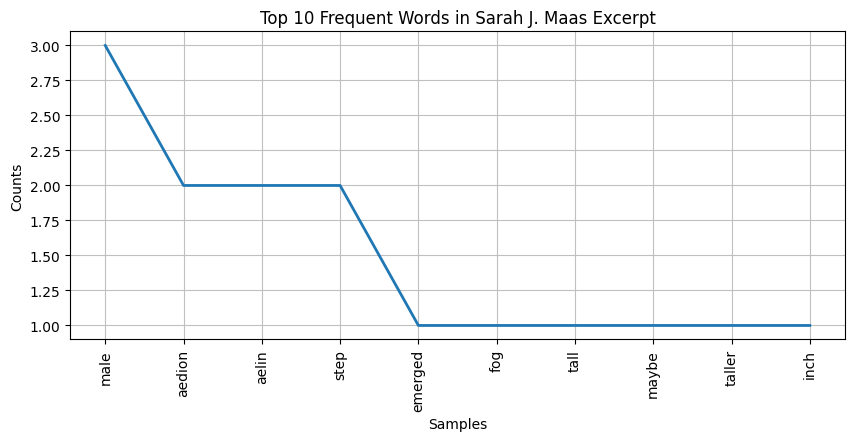

In [11]:
# Compute word frequency distribution (lowercased)
clean_words_lower = [w.lower() for w in filtered_tokens]
fdist = FreqDist(clean_words_lower)

# Plot top 10 most frequent words
plt.figure(figsize=(10, 4))
fdist.plot(10, title="Top 10 Frequent Words in Sarah J. Maas Excerpt", cumulative=False)
plt.show()

## **POS Tagging, Noun/Verb Extraction and Adjective Root Words**

In this step, we select a feature-rich sentence from the Rowan excerpt:

*"The male emerged from the fog; tall - maybe taller than Aedion himself, if only by an inch, powerfully built, and heavily armed both above and beneath his pale grey surcoat and hood."*

We execute the following three sub-tasks:
1. **POS Tagging:** Using NLTK's `pos_tag()` to assign Penn Treebank tags to every token.
2. Noun & Verb Extraction:
  * Nouns: Filter tokens whose tag starts with `NN` (e.g., `NN`, `NNS`, `NNP`).
  * Verbs: Filter tokens whose tag starts with `VB` (e.g., `VB`, `VBD`, `VBG`, `VBN`)
3. Adjective Analysis:
  * Filter tokens tagged as Adjectives (`JJ`, `JJR`, `JJS`).
  * Compute the total count of adjectives.
  * Apply WordNet Lemmatization (`pos=wordnet.ADJ`) to extract their canonical root form (e.g., "taller" $\rightarrow$ "tall").

In [12]:
# Target descriptive sentence from the new excerpt
target_sentence = sentences[0]
print("TARGET SENTENCE FOR POS ANALYSIS:")
print(f"\"{target_sentence}\"\n")

# Tokenize sentence into individual words
words_in_sent = word_tokenize(target_sentence)

# Perform Part-of-Speech Tagging
pos_tags = pos_tag(words_in_sent)

print("1. FULL POS TAGGING (Token, Penn-Treebank Tag)")
for word, tag in pos_tags:
    print(f"{word:<15} : {tag}")

# Extract Nouns (NN*) and Verbs (VB*)
nouns = [word for word, tag in pos_tags if tag.startswith('NN')]
verbs = [word for word, tag in pos_tags if tag.startswith('VB')]


print(f"\n2. EXTRACTED NOUNS ({len(nouns)} found)")
print(nouns)

print(f"\n3. EXTRACTED VERBS ({len(verbs)} found)")
print(verbs)

# Extract Adjectives (JJ*) and derive their root lemmas
adjectives = [word for word, tag in pos_tags if tag.startswith('JJ')]
adj_roots = [lemmatizer.lemmatize(adj.lower(), pos=wordnet.ADJ) for adj in adjectives]

print(f"\n4. ADJECTIVE ANALYSIS")
print(f"Total Number of Adjectives : {len(adjectives)}")
print(f"Original Adjectives        : {adjectives}")
print(f"Root Words (Lemmas)        : {adj_roots}")

TARGET SENTENCE FOR POS ANALYSIS:
"The male emerged from the fog; tall - maybe taller than Aedion himself, if only by an inch,
powefully built, and heavily armed both above and beneath his pale grey surcoat and hood."

1. FULL POS TAGGING (Token, Penn-Treebank Tag)
The             : DT
male            : NN
emerged         : VBD
from            : IN
the             : DT
fog             : NN
;               : :
tall            : CC
-               : :
maybe           : RB
taller          : NN
than            : IN
Aedion          : NNP
himself         : PRP
,               : ,
if              : IN
only            : RB
by              : IN
an              : DT
inch            : NN
,               : ,
powefully       : RB
built           : VBN
,               : ,
and             : CC
heavily         : RB
armed           : VBD
both            : DT
above           : IN
and             : CC
beneath         : VB
his             : PRP$
pale            : NN
grey            : NN
surcoat         : 